# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose the Census Income data set. 

2. The label is 'income_binary'. I am predicting wther an individual's annual income is greater than $50,000, or less than or equal to. 

3. I plan to use demographic and employment related features such as: age, education, marital_status, occupation, workclass, hours_per_week, capital_gain, capital_loss, relationship, sex.  

4. A model that predicts whether an individual's income exceeds $50,000 can help organizations better understand income trends across different demographic and employment groups. the organization described in the business brief could use this model to help clients identify factors associated with higher income, support workforce and economic analysis. This cam help provide valuable insights for planning, policy development, and targetted services. 

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64


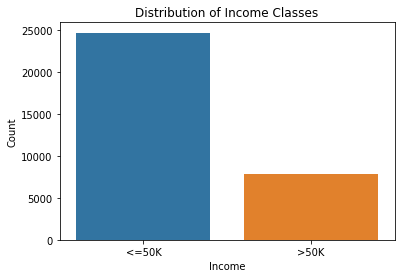

In [3]:
print(df["income_binary"].value_counts())
sns.countplot(data=df, x="income_binary")
plt.title("Distribution of Income Classes") 
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64
age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income_binary      object
dtype: object


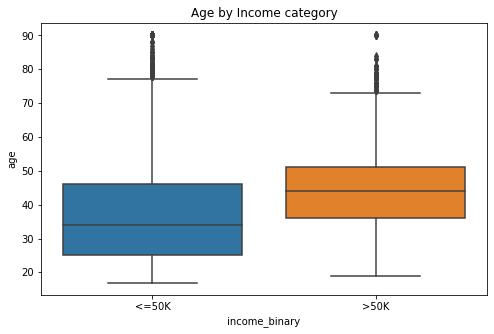

In [4]:
print(df.isnull().sum())
print(df.dtypes)
df.describe()

plt.figure(figsize=(8,5))
sns.boxplot(
data=df,
x="income_binary",
y="age"  
)

plt.title("Age by Income category")
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

The data exploration showed that the target variable (`income_binary`) is somewhat imbalanced, with more individuals earning less than or equal to $50,000 than those earning more than $50,000. This imbalance should be considered when training and evaluating the model. However, although the classes were somewhat imbalanced, the imbalance was not severe, so I chose not to apply resampling techniques and instead evaluated the model using both accuracy and F1 score.

I also found that several features contain missing values, including workclass (1,836 missing values), occupation (1,843), native-country (583), age (162), and hours-per-week (325). These missing values will need to be handled before training the model. The dataset contains both numerical features (such as age, education-num, capital-gain, capital-loss, and hours-per-week) and categorical features (such as workclass, education, occupation, race, sex_selfID, and native-country), so categorical variables will need to be encoded before they can be used in a machine learning model.

The boxplot comparing age and income shows that individuals earning more than $50K tend to be older on average than those earning $50K or less, suggesting that age may be a useful predictor of income.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. The Census Income dataset may contain biases because it is based on historical census data collected in 1994. Historical income patterns may reflect discrimination and unequal opportunities across different demographic groups. Features such as sex, marital status, education, occupation, and relationship status could act as proxies for protected characteristics or socioeconomic status.

2. Incorrect predictions could negatively affect individuals if the model were used for decisions involving employment, lending, insurance, or financial assistance. Certain demographic groups could be unfairly classified as lower-income due to historical bias in the data, leading to unequal treatment or reduced opportunities. For this reason, it is important to evaluate the model for fairness in addition to overall accuracy.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [5]:
# Remove rows with missing values
df = df.dropna()

# Convert labels to 0 and 1
df["income_binary"] = df["income_binary"].map({
    "<=50K": 0,
    ">50K": 1
})

# One-hot encode categorical variables
df = pd.get_dummies(df, drop_first=True)

In [6]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [7]:
print(df["income_binary"].unique())

[0 1]


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I prepared the data by first removing rows with missing values using dropna to ensure teh model would not encounter errors during training, Since the label column (income binary) contained text values (less/more than or equal to 50k), I converted them into binary values (0 and 1), where 0 represents incomes less than or equal to $50k and 1 represents incomes greater than or equal to $50k.

Since many of the features were categorical, I used one-hot encoding (pd.get_dummies()) to convert them into numerical variables that Logistic Regression can use. I kept the remaining features because they may all contribute useful information for predicting income. Finally, I scaled the feature values using StandardScaler because Logistic Regression generally performs better when numerical features are on a similar scale.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [8]:
# Create labeled examples from the dataset
X = df.drop("income_binary", axis=1)
y = df["income_binary"]

In [9]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
)

In [10]:
print(X_train.dtypes)

age                               float64
fnlwgt                              int64
education-num                       int64
capital-gain                        int64
capital-loss                        int64
                                   ...   
native-country_Thailand             uint8
native-country_Trinadad&Tobago      uint8
native-country_United-States        uint8
native-country_Vietnam              uint8
native-country_Yugoslavia           uint8
Length: 96, dtype: object


In [11]:
# Train, test and evaluate your model
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="binary")

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.8516150740242261
F1 Score: 0.6716306775874906


In [12]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", grid.best_score_)

Best Parameters: {'C': 100}
Best F1 Score: 0.6632602866247307


In [13]:
print(X.columns)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Local-gov', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay', 'education_11th',
       'education_12th', 'education_1st-4th', 'education_5th-6th',
       'education_7th-8th', 'education_9th', 'education_Assoc-acdm',
       'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate',
       'education_HS-grad', 'education_Masters', 'education_Preschool',
       'education_Prof-school', 'education_Some-college',
       'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-clea

In [14]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

final_predictions = best_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions, average="binary")

print("Final Accuracy:", final_accuracy)
print("Final F1 Score:", final_f1)

Final Accuracy: 0.8517833109017496
Final F1 Score: 0.671880819366853


In [15]:
# Interpret your model's outputs 
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients.head(10))

                              Feature  Coefficient
28  marital-status_Married-civ-spouse     0.994713
3                        capital-gain     0.859305
2                       education-num     0.511821
55              sex_selfID_Non-Female     0.406366
5                      hours-per-week     0.365356
0                                 age     0.346173
50                  relationship_Wife     0.274242
35         occupation_Exec-managerial     0.273550
4                        capital-loss     0.263283
54                         race_White     0.205022


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose Logistic Regression because the goal of this project was to predict whether an individual's annual income is greater than $50,000, making this a binary classification problem. Logistic Regression is well suited for binary outcomes and works well with structured tabular data like the Census Income dataset. After converting the categorical variables into numerical features using one-hot encoding and scaling the data, Logistic Regression was an appropriate and interpretable model for this problem.


2. I used GridSearchCV to test different values of the regularization parameter C. The best value found was C = 100, which produced the highest cross-validation F1 score. After retraining the model with this parameter, the final model achieved an accuracy of approximately 85.2% and an F1 score of approximately 0.672. The performance improved slightly compared to the default model.


3. The Logistic Regression coefficients indicate how each feature influences the likelihood that a person earns more than 50k per year. Positive coefficients increase the probability of belonging to the higher income class, while negative coefficients decrease it. In my model, features such as being married (marriedcivspouse), higher capital gain, higher education level, working more hours per week, and older age had some of the positive coefficients, suggesting that these factors are associated with a greater likelihood of earning more than $50k. 


4. This dataset includes demographic features such as sex, race, age, marital status, and native country, which may reflect historical or societal biases. If the model is used to support decisions related to employment, lending, or financial services, incorrect predictions could unfairly disadvantage certain individuals or demographic groups. For example, someone who actually earns more than $50,000 could be incorrectly classified as earning less, or vice versa. Because some features are closely related to protected characteristics, it is important to evaluate the model for fairness and ensure that its predictions are not biased against particular groups.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [16]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [17]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.Input(shape=(n_features,)))
# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.

#I used two hidden layers with 32 and 16 units. This provides enoughcapacity to learn patterns in the data without making the network
# unnecessarily complex. I chose the ReLU activation function because
# it is efficient and helps the model learn non-linear relationships.

nn_model.add(keras.layers.Dense(32, activation='relu'))
nn_model.add(keras.layers.Dense(16, activation='relu'))


# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
nn_model.add(keras.layers.Dense(1, activation='sigmoid'))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                3104      
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 3,649
Trainable params: 3,649
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [18]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

# I chose a learning rate of 0.01 because it is a common default for 
# SGD. It allows the model to learn gradually while helping prevent
# unstable updates during training.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [19]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [20]:
nn_model.compile(
optimizer=sgd_optimizer,
loss=loss_fn,
 metrics=['accuracy']
)

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [21]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [22]:
logger = ProgBarLoggerNEpochs(num_epochs=25)

In [23]:
# Decision: How many epochs? Add a comment.

# Initially i had 100 epochs, then I experimented and chose
# 25 epochs because it provides enough training iterations for 
# the model to learn meaningful patterns while allowing me to 
# monitor the validation performance for signs of overfitting. 

t0 = time.time() # start time

num_epochs = 25

history = nn_model.fit(
X_train_scaled,
y_train,
epochs=num_epochs,
validation_split=0.2,
callbacks=[logger],
verbose=0
) 

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Elapsed time: 20.57s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



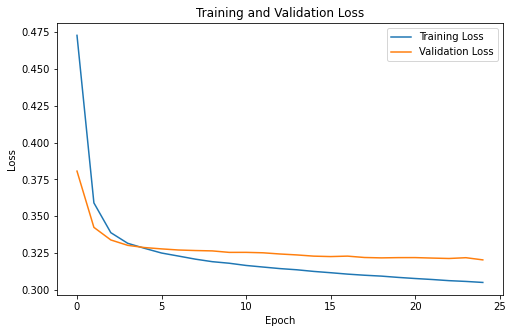

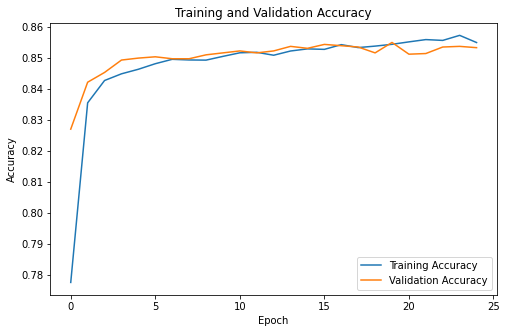

In [24]:
# Plot training loss and validation loss over epochs

# A new figure for the loss graph
plt.figure(figsize=(8,5))
#plots the training loss for each epoch
plt.plot(history.history['loss'], label='Training Loss') 
#plots the validation loss for each epoch
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch') #labels x-axis
plt.ylabel('Loss') #labels y-axis
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


# Plot training accuracy and validation accuracy over epochs
#same thing but for training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [25]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

y_pred_prob = nn_model.predict(X_test_scaled)
# Converts probabilities to binary predictions (0 or 1)
y_pred = (y_pred_prob >= 0.5).astype(int)


In [26]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, y_pred)
nn_f1 = f1_score(y_test, y_pred)

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network F1 Score:", nn_f1)

Neural Network Accuracy: 0.8529609690444145
Neural Network F1 Score: 0.6817188638018936


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. For the neural network, I used two hidden layers with 32 and 16 units because they provide enough capacity to learn patterns without making the model too complex. I used the ReLU activation function for the hidden layers because it helps the model learn non-linear relationships efficiently, and a sigmoid activation function in the output layer because this is a binary classification problem. I chose a learning rate of 0.01 for the SGD optimizer because it is a common value that allows the model to learn steadily. I trained the model for 25 epochs, which gave it enough time to learn while allowing me to monitor for overfitting.


2. The training curves showed that the training and validation loss both decreased over time, while the training and validation accuracy increased steadily. The two curves stayed close together, which suggests that the model generalized well and did not show significant signs of overfitting or underfitting.


3. On the test set, the neural network achieved an accuracy of 85.30% and an F1 score of 0.6817. These results were consistent with the training curves, so I was not surprised by its performance. Compared with the previous model, the neural network had a slightly lower accuracy but a slightly higher F1 score, indicating that both models performed similarly overall.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [28]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Foundational Model': [final_accuracy, final_f1],   # <-- comma here
    'Neural Network': [nn_accuracy, nn_f1]
})

print(results.to_string(index=False))

   Metric  Foundational Model  Neural Network
 Accuracy            0.851783        0.852961
 F1 Score            0.671881        0.681719


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The neural network performed slightly better than the foundational model. It achieved a slightly higher accuracy (85.30% vs. 85.18%) and a higher F1 score (0.6817 vs. 0.6719). Although the improvements were small, they show that the neural network was able to make slightly better predictions overall.


2. The neural network required more time and effort to build, train, and tune than the foundational model. Since the performance improvement was only slight, the added complexity may not be worth it in every situation. However, if achieving the best possible prediction performance is important, the neural network could still be a good choice.


3. I would recommend the neural network because it achieved the highest accuracy and F1 score in this project. However, the improvement over the Logistic Regression model was relatively small. If the company values simplicity, interpretability, and faster training, the Logistic Regression model would also be a strong choice. 


4. If I had more time, I would experiment with different neural network architectures, such as changing the number of hidden layers, the number of neurons, and the learning rate. I would also try techniques to address class imbalance, such as using class weights or resampling, and perform additional feature engineering to see if the model's performance could be improved further.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used AI during the coding and debugging stages of this capstone. It helped me understand error messages, clarify assignment instructions, and explain parts of the neural network implementation so I could complete each step with a better understanding of what the code was doing.

2. The most challenging part of the capstone was building and training the neural network because there were many components that had to work together correctly, such as defining the architecture, compiling the model, and fixing errors like undefined variables. AI helped me understand what the error messages meant and explain why certain choices, such as the number of hidden layers and learning rate, made sense. One prompt that was especially helpful was asking AI to explain each section of the neural network code

3. verified my work by running each code cell and checking that it produced the expected output without errors. I also compared my model's accuracy, F1 score, and training graphs to make sure the results were reasonable and consistent.

4. Next time, I would spend more time understanding each step before moving on so that I rely less on debugging later. I would also ask AI more conceptual questions earlier in the process instead of only asking for help after I encountered an error. 